In [1]:
# Create a Machine Learning that can predict profit based on sales and other features, (Regression Task)
# Predict Customer Type based on transaction data, (Classification Task)
'''
1. Import necessary libraries
2. Load the dataset and Explore (EDA) the data
3. Preprocess the data (handle missing values, encode categorical variables, feature scaling)
4. Split the dataset into training and testing sets
5. Train a regression model to predict profit based on sales and other features
6. Evaluate the regression model using appropriate metrics (e.g., RMSE, R-squared)
7. Train a classification model to predict customer type based on transaction data
8. Evaluate the classification model using appropriate metrics (e.g., accuracy, precision, recall, F1-score)
9. Visualize the results and interpret the findings 


'''

'\n1. Import necessary libraries\n2. Load the dataset and Explore (EDA) the data\n3. Preprocess the data (handle missing values, encode categorical variables, feature scaling)\n4. Split the dataset into training and testing sets\n5. Train a regression model to predict profit based on sales and other features\n6. Evaluate the regression model using appropriate metrics (e.g., RMSE, R-squared)\n7. Train a classification model to predict customer type based on transaction data\n8. Evaluate the classification model using appropriate metrics (e.g., accuracy, precision, recall, F1-score)\n9. Visualize the results and interpret the findings \n\n\n'

In [2]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import sci-kit for machine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ignore Warnings
# import warnings
# warnings.filterwarnings('ignore')



In [ ]:

# Load the dataset
df = pd.read_csv('ecommerce_bigdata.csv')

In [12]:
import pandas as pd

# Skip rows that cause parsing errors
df = pd.read_csv('ecommerce_bigdata.csv', encoding='latin-1', on_bad_lines='skip')
# OR keep track of skipped rows
df = pd.read_csv('ecommerce_bigdata.csv', encoding='latin-1', on_bad_lines='warn')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16524\2117614060.py:6: ParserWarning: Skipping line 7: expected 3 fields, saw 4
Skipping line 26: expected 3 fields, saw 4
Skipping line 38: expected 3 fields, saw 5
Skipping line 45: expected 3 fields, saw 4
Skipping line 74: expected 3 fields, saw 4
Skipping line 77: expected 3 fields, saw 4

  df = pd.read_csv('ecommerce_bigdata.csv', encoding='latin-1', on_bad_lines='warn')


In [14]:
# Display the first few rows of the dataset
df.head()

,,ñ; Ìhug @é<J ¼RðÛâVFü¤rïá aÒQD¹j Å*R,ímB$äGóÎ ¯æâË× #A½1âGyõ¡ÎíU 4m:b°Éa[XÔ
0,Ù}~½b÷Ú?®,NaN,NaN
1,îD½`ÖËõÿíà9,C\1§\ßmòñ©8ÒÓÞ@x¿ wUq°s£#ç_¥ùøUØz...,NaN
2,tÌ?ï£NH`4 ëÛyòI inP´õoÉPã _Òç6èÏ®õ½ø...,±×ýsëRÈ¤y8×ø3ÎÃØØl²JÏ7º ³÷j¾ \|ÐÞ< Ñ...,NaN
3,þIrj)¬«¢ Ü}'ütÝÞtl&X¶æIÀ®½_YS»-/qe...,ý×»ÇõÿèhÐúñ,NaN
4,"S p·ý§[@æ\t}DÐJ®©õï^¶ÓÙk8è­xLjÃ""¾ ¢\Õ...",8Ù ö?pjç0é1SÞ±ð+á \Î±¨y¥öJ'v3ÉÊÃ\tÑ^´w,NaN


In [15]:
# Preprocess the data (handle missing values, encode categorical variables, feature scaling)

# Check for empty values in the dataset
# Check for Duplicate rows
# Wrong format of data in the dataset
# Wrong data type in the dataset

#df = df.dropna()  # Handle missing values

# Check for missing values
df.isnull().sum()


                                                          0
ñ;Ìhug
@é<J ¼RðÛâVFü¤rïá
aÒQD¹j
Å*R             53
ímB$äGóÎ¯æâË×
#A½1âGyõ¡ÎíU4m:b°Éa[XÔ    78
dtype: int64

In [159]:
# Summary statistics of the dataset
df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


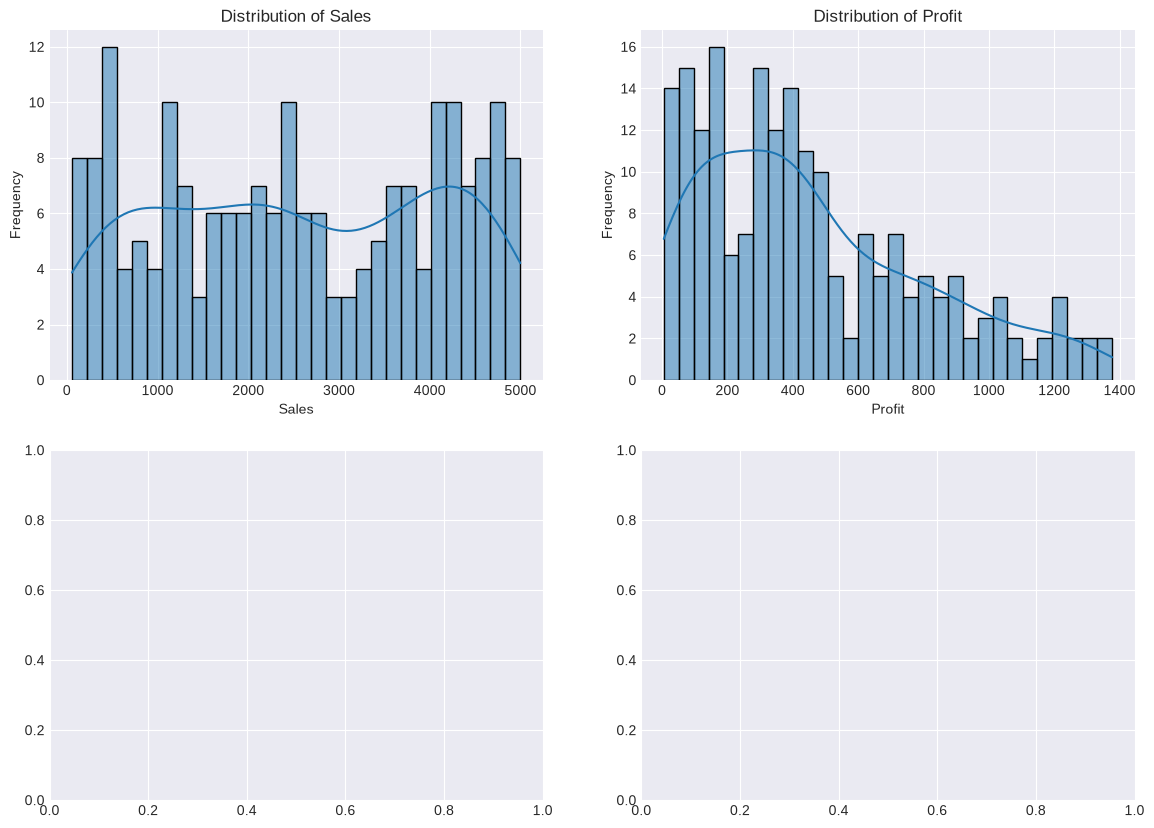

In [160]:
# Data Visualization
# Setup the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# 1 Plot Distribution of Sales
sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sales')   
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

# 2 Plot Distribution of Profit
sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')

plt.show()

# Exercises 2
# Plot sales by product category (Boxplot) 

# Plot the relationship between Sales and Profit (Scatter plot)

In [161]:
# Step 4: 3. Feature Engineering: Selecting and creating relevant features that will help the model learn better.
# Create a copy of the original dataframe to avoid modifying it directly
df_processed = df.copy()


# Convert Date to datetime format and extract relevant features (e.g., year, month, day)
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['Weekday'] = df_processed['Date'].dt.weekday

In [163]:
# Encoded categorical variables (text → numbers)
# Key Concepts
'''
What happens if we don't convert categorical variables to numbers? 

'''
# Why? Machine learning algorithms work with numerical data. 
# Categorical variables need to be converted to numerical representations for the model to understand 
# and process them effectively.

label_encoder = {}

categorical_columns = ['Region', 'ProductCategory', 'CustomerType']  # Replace with your categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col + '_Encoded'] = le.fit_transform(df_processed[col])
    label_encoder[col] = le  # Store the label encoder for future use
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')


Encoded Region: {'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
Encoded ProductCategory: {'Beverages': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Food': np.int64(3), 'Household Products': np.int64(4)}
Encoded CustomerType: {'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [165]:
# Drop the original categorical columns after encoding and TransactionID (Not useful for prediction)
df_processed.drop(['TransactionID', 'Date', 'Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True)

print("Processed DataFrame after encoding and dropping unnecessary columns:")
df_processed.head()

Processed DataFrame after encoding and dropping unnecessary columns:


,Sales,Profit,Month,Day,Weekday,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,6,16,1,1,2,2
1,3283,944.32,2,12,3,0,2,1
2,4049,967.10,3,1,6,2,3,0
3,4331,434.57,6,3,2,3,4,0
4,3283,340.48,1,21,2,3,4,1


In [167]:
# Step 5: Split the dataset into training and testing sets
# Define features and target variable for regression task (predicting profit)
# Regression Task: Predicting Profit based on Sales
print('Regression: Predicting Profit based on Sales')

# Prepare the features (X) and target variable (y) for regression
X_reg = df_processed.drop('Sales', axis=1)  # Features (all columns except 'Profit') Independent variables
y_reg = df_processed['Profit']  # Target variable (Profit) Dependent variable

# Split the dataset into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# What is a random state?
# A random state is a seed value that ensures reproducibility of the results.

print(f'Regression Data Split: ')
print(f"Training set size: {X_train_reg.shape[0]} samples")
print(f"Testing set size: {X_test_reg.shape[0]} samples")


Regression: Predicting Profit based on Sales
Regression Data Split: 
Training set size: 160 samples
Testing set size: 40 samples


In [168]:
# Train multiple regression models and evaluate their performance
# 1. Linear Regression
# 2. Decision Tree Regressor
# 3. Random Forest Regressor

regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

print("\nRegression Model Evaluation:")
regression_results = {}

for name, model in regression_models.items():
    # Train the model
    model.fit(X_train_reg, y_train_reg)
    
    # Make predictions on the test set
    y_pred_reg = model.predict(X_test_reg)
    
    # Evaluate the model and calculate RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    regression_results[name] = {'RMSE': rmse, 'R-squared': r2}
    
    print(f"{name}: RMSE = {rmse:.4f}, R-squared = {r2:.4f}")

    # Store results 
    regression_results[name] = {
        'model': model,
        'RMSE': rmse,
        'mse': mean_squared_error(y_test_reg, y_pred_reg),
        'R-squared': r2,
        'predicted_profit': y_pred_reg
    }

    print(f"{name} model trained and evaluated successfully.")
    print(f"Mean Squared Error (MSE): {regression_results[name]['mse']:.2f}")
    print(f"Root Mean Squared Error (RMSE): {regression_results[name]['RMSE']:.4f}")
    print(f"R-squared: {regression_results[name]['R-squared']:.4f}")
    print(f"Interpretation: {regression_results[name]['predicted_profit'][:5]}")  # Display first 5 predictions


Regression Model Evaluation:
Linear Regression: RMSE = 0.0000, R-squared = 1.0000
Linear Regression model trained and evaluated successfully.
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.0000
R-squared: 1.0000
Interpretation: [ 41.94 905.95 496.96 712.17 587.69]
Decision Tree Regressor: RMSE = 23.4780, R-squared = 0.9951
Decision Tree Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 551.21
Root Mean Squared Error (RMSE): 23.4780
R-squared: 0.9951
Interpretation: [ 40.04 899.24 510.68 725.   567.64]
Random Forest Regressor: RMSE = 6.6446, R-squared = 0.9996
Random Forest Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 44.15
Root Mean Squared Error (RMSE): 6.6446
R-squared: 0.9996
Interpretation: [ 42.0606 901.4156 503.2668 716.7321 588.3444]
